<div style="display: flex; align-items: center;">
    <img alt="udeA logo" height="140px" src="https://github.com/freddyduitama/images/blob/master/logo.png?raw=true" style="width:107px;height:152px; margin-right: 40px;">
    <div style="text-align: center;">
        <h1><b><font color='0B5345'>Trabajo 4: Imagenes médicas</font></b></h1>
        <h2><font color='0B5345'>Luisa Fernanda Enciso - Juan Diego Caguasango</font></h2>
    </div>
</div>


## 1. Preguntas teóricas 20%


## 2. Implementación 60%


In [1]:
# Manipulación numérica y tabular
import numpy as np
import pandas as pd
from collections import defaultdict

# Gráficas y visualización de resultados
import matplotlib.pyplot as plt
import seaborn as sns

# Definición de modelos y procesamiento de imágenes
import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D , MaxPool2D , Flatten , Dropout , BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import ReduceLROnPlateau

# División de datos y métricas de evaluación
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Procesamiento de imágenes
import cv2

# Manejo de carpetas y rutas
import os

import os


import random
from collections import Counter

In [2]:
base_dir = r"D:\Luisa\imagenes\archive\Mini_DDSM_Upload"

### a. Exploración del dataset

El dataset Mini-DDSM se trata de un conjunto de datos de mamografías diseñado específicamente para investigaciones relacionadas con imágenes médicas, y en este caso particular, para la estimación automática de la edad a partir de mamogramas.

Contenido y propósito del dataset:
Origen: El Mini-DDSM proviene del Digital Database for Screening Mammography (DDSM), que es un repositorio más amplio y conocido de imágenes mamográficas.

Problema con el DDSM original: Las imágenes de alta resolución del DDSM original solo pueden ser accedidas con un software que actualmente está dañado o no funciona correctamente.

Solución: Los autores usaron un web crawler para descargar miniaturas (thumbnails) de las imágenes mamográficas y los metadatos asociados, incluyendo la edad de las pacientes, para crear este nuevo subconjunto llamado Mini-DDSM.

Aplicación: Con esas imágenes y la edad de las pacientes, entrenaron un modelo de aprendizaje automático (Random Forest Regressor) para predecir la edad de una persona a partir de su mamografía.

In [3]:
class_names = ["Normal", "Cancer", "Benign"]

for class_name in class_names:
    folder_path = os.path.join(base_dir, class_name)
    extensiones = set()

    if not os.path.exists(folder_path):
        print(f"[ADVERTENCIA] Carpeta no encontrada: {folder_path}")
        continue

    for file in os.listdir(folder_path):
        ext = os.path.splitext(file)[1]
        extensiones.add(ext.lower())

    print(f"Carpeta: {class_name} - Extensión: {extensiones}")


Carpeta: Normal - Extensión: {'.png'}
Carpeta: Cancer - Extensión: {'.png'}
Carpeta: Benign - Extensión: {'.png'}


In [4]:
# Nombres de clases
class_names = ["Normal", "Cancer", "Benign"]

# Contar imágenes por clase
image_counts = {}

for class_name in class_names:
    folder_path = os.path.join(base_dir, class_name)
    if not os.path.exists(folder_path):
        print(f"Carpeta no encontrada: {folder_path}")
        continue
    files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    image_counts[class_name] = len(files)

# Mostrar resultados
print("Cantidad de imágenes por clase:")
for class_name, count in image_counts.items():
    print(f"{class_name}: {count}")

Cantidad de imágenes por clase:
Normal: 2728
Cancer: 3596
Benign: 3360


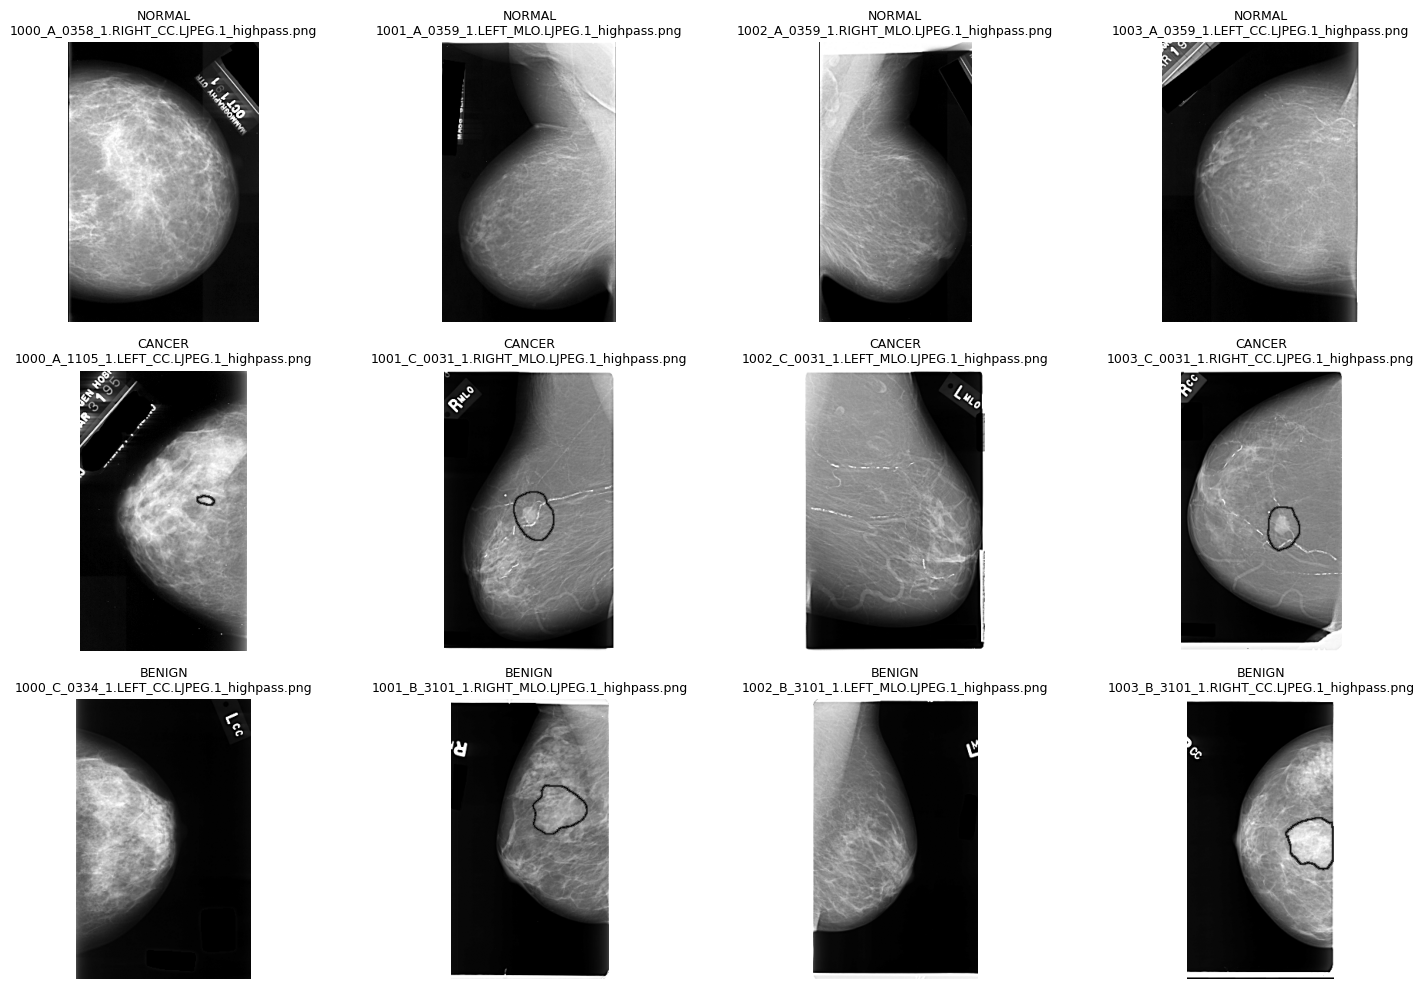

In [5]:
normal_folder = os.path.join(base_dir, "Normal")
cancer_folder = os.path.join(base_dir, "Cancer")
benign_folder = os.path.join(base_dir, "Benign")

# Obtener archivos
normal_files = os.listdir(normal_folder)
cancer_files = os.listdir(cancer_folder)
benign_files = os.listdir(benign_folder)

# Número de imágenes a mostrar por clase
n_images = 4

# Diccionario de clases y sus rutas
classes = {
    "Normal": (normal_folder, normal_files),
    "Cancer": (cancer_folder, cancer_files),
    "Benign": (benign_folder, benign_files)
}

# Crear figura
plt.figure(figsize=(4 * n_images, 10))

# Iterar sobre cada clase y graficar
for row_idx, (class_name, (folder, file_list)) in enumerate(classes.items()):
    for col_idx, img_name in enumerate(file_list[:n_images]):
        img_path = os.path.join(folder, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        ax_idx = row_idx * n_images + col_idx + 1
        plt.subplot(len(classes), n_images, ax_idx)
        plt.imshow(img, cmap="gray")
        plt.title(f"{class_name.upper()}\n{img_name}", fontsize=9)
        plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
# Clases
class_names = ["Normal", "Benign", "Cancer"]
sample_size = 100  # Número de imágenes a analizar por clase

# Resultados
dimensions = []
mean_intensities = []
std_intensities = []

for class_name in class_names:
    folder_path = os.path.join(base_dir, class_name)
    if not os.path.exists(folder_path):
        print(f"[ADVERTENCIA] Carpeta no encontrada: {folder_path}")
        continue

    # Lista de archivos de imagen válidos
    files = [f for f in os.listdir(folder_path) if f.lower().endswith((".png", ".jpg", ".jpeg"))]
    sampled_files = random.sample(files, min(sample_size, len(files)))

    for file in sampled_files:
        img_path = os.path.join(folder_path, file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        # Guardar dimensiones e intensidades
        dimensions.append(img.shape)
        mean_intensities.append(np.mean(img))
        std_intensities.append(np.std(img))

# ------------------------
# Resultados
# ------------------------

# 1. Dimensiones
dim_counts = Counter(dimensions)
print("\n Dimensionalidad")

if len(dim_counts) == 1:
    print("Todas las imágenes muestreadas tienen dimensiones homogéneas.")
else:
    print("Las imágenes muestreadas tienen dimensiones heterogéneas. Se debe redimensionar.")

# 2. Intensidades
print("\n Intensidades")
print(f"  Intensidad media promedio: {np.mean(mean_intensities):.2f}")
print(f"  Desviación estándar promedio: {np.mean(std_intensities):.2f}")
print(f"  Rango global de intensidades: {np.min(mean_intensities):.1f} – {np.max(mean_intensities):.1f}")

if np.std(mean_intensities) < 5:
    print("Las intensidades son razonablemente homogéneas.")
else:
    print("Hay variación en brillo/contraste. Se debe hacer normalización.")



 Dimensionalidad
Las imágenes muestreadas tienen dimensiones heterogéneas. Se debe redimensionar.

 Intensidades
  Intensidad media promedio: 75.29
  Desviación estándar promedio: 78.43
  Rango global de intensidades: 28.9 – 124.9
Hay variación en brillo/contraste. Se debe hacer normalización.


### b. Análisis de la red neuronal

In [ ]:
from tensorflow.keras import layers, models

img_size = 150
model = models.Sequential()
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(img_size,
img_size, 1)))
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(3, activation='softmax'))

# Compilar el modelo
model.compile(optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy'])

# Mostrar resumen del modelo
model.summary()
history = model.fit(x_train, y_train, epochs=10, validation_split=0.2,
batch_size=32)

## 3. Propuesta y aplicación de mejoras 20%


## Conclusiones


## Referencias
